### Imports

In [ ]:
import subprocess
import os
# from unlearning_metrics.evaluate.config import parameters
from _old.config import parameters
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


from models.archs.ConvNet import ConvNet
# from config import parameters
from unlearn.GA import GA
from data.utils import split_forget_retain
from trainer.utils import get_memory_footprint, get_model_weight_norm, check_accuracy

### Set configs for the experiment

In [ ]:
exp_config = {
    "GRAND_SEED": 42,

    # data loader stuff
    "data": {
        "batch_size": 128,
        "class_to_replace": 0,
        "percent_to_replace": None,
        "num_workers": 0,
    }

    "training": {
        "num_epochs": 30,
        
    }
    
}

### Data loaders

/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


========== DATALOADER INFO
Dataset: CIFAR-10
Train: 45000 images for training
Val: 5000 images for validation
Test: 10000 images for testing
Replaced class 0 in train, val, and test
Training augmentation = randomcrop(32,4) + randomhorizontalflip + colorjitter + randomrotation + normalize
Validation/Test augmentation = normalize

n
Forget set: 4500 items
Retain set: 40500 items
Forget set: 500 items
Retain set: 4500 items
Forget set: 1000 items
Retain set: 9000 items


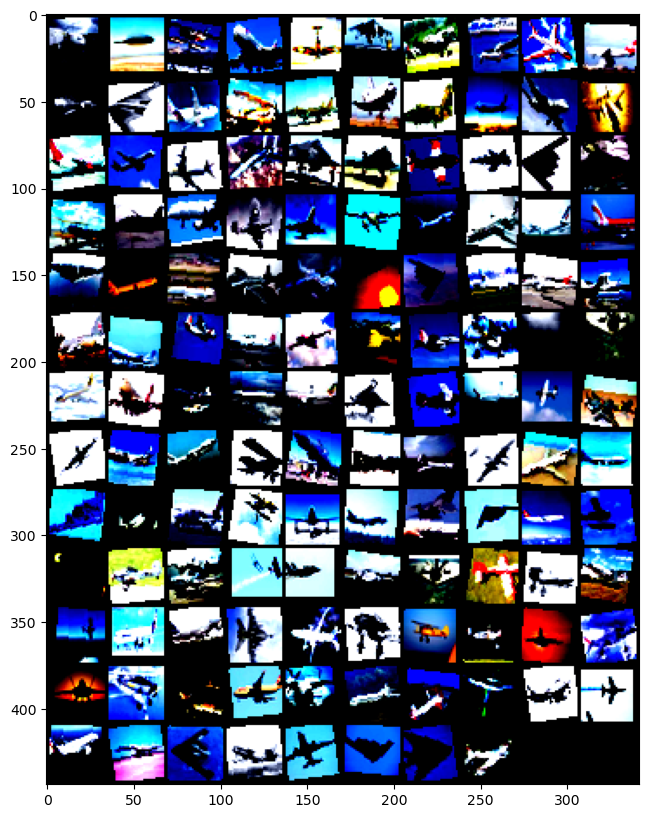

In [ ]:
from torchvision.utils import make_grid
from data.dataloaders import cifar10_dataloaders
from data.utils import split_forget_retain
# # ... define a dataset, forget set, and retain set


full_train, full_val, full_test = cifar10_dataloaders(
    data_dir="data/CIFAR10", 
    batch_size=128, 
    num_workers=0, 
    seed=exp_config["GRAND_SEED"], 
    class_to_replace=None, 
    percent_to_replace=None
    )


marked_train, marked_val, marked_test = cifar10_dataloaders(
    data_dir="data/CIFAR10", 
    batch_size=128, 
    num_workers=0, 
    seed=exp_config["GRAND_SEED"], 
    class_to_replace=exp_config["class_to_replace"], 
    percent_to_replace=exp_config["percent_to_replace"], 
    only_mark=True
    )
forget_train, retain_train = split_forget_retain(marked_train, batch_size=exp_config["batch_size"], seed=exp_config["GRAND_SEED"])
forget_val, retain_val = split_forget_retain(marked_val, batch_size=exp_config["batch_size"], seed=exp_config["GRAND_SEED"])
forget_test, retain_test = split_forget_retain(marked_test, batch_size=exp_config["batch_size"], seed=exp_config["GRAND_SEED"])

X, y = next(iter(forget_train))
plt.figure(figsize=(18,10))
plt.imshow(make_grid(X, nrow=10).permute((1,2,0)));

### The GA  regimen

In [ ]:
import json
import numpy as np

def GA_regimen(model, dataloaders, num_epochs, criterion, optimizer, print_freq, measure_every, device, name = "run_1", save_folder = "results"):

    # create save folder if it doesn't exist
    if not os.path.exists(save_folder):
        print(f"{save_folder} doesn't exist - creating it...")
        os.makedirs(save_folder, exist_ok=True)

    # For each epoch ...
    for k in range(1, num_epochs+1):

        # ... do one round of GA,
        model, top1_avg = GA(dataloaders["forget_train"], model, criterion, optimizer, epoch = k, print_freq = print_freq, device = device)

        # ... eval on forget set and retain set
        forget_acc = check_accuracy(model, data_loader = dataloaders["forget_train"], device = device)
        retain_acc = check_accuracy(model, data_loader = dataloaders["retain_test"], device = device)
        print(f"Epoch: {k} | Forget Set Accuracy: {forget_acc:.3f} | Retain Set Accuracy: {retain_acc:.3f}\n")

        # ... and if we're saving out,
        if k % measure_every == 0:
            
            # ... create an epoch-level subfolder if it doesn't exist
            epoch_save_folder = os.path.join(save_folder, f"epoch_{k}")
            if not os.path.exists(epoch_save_folder):   
                print(f"{epoch_save_folder} doesn't exist - creating it...")
                os.makedirs(epoch_save_folder, exist_ok=True)
            
            # ... bind results to a dictionary,
            results = {
                "name": name,
                "epoch": k,
                "forget_acc": forget_acc,
                "retain_acc": retain_acc
            }

            # ... and save them
            with open(os.path.join(epoch_save_folder, f"{name}.json"), "w") as f:
                json.dump(results, f, indent=4)

    return model

### Protocol for several runs

In [ ]:
import random

def run_experiment(seed = 42, num_runs_each = 2, num_epochs = 20, measure_every = 2, main_folder = "results", classes = list(range(10))):

    # apply seed to params, so all downstream functions can use it
    # parameters["seed"] = seed

    # Make folder if it doesnt already exist
    if not os.path.exists(main_folder):
        print(f"{main_folder} doesn't exist - creating it...")
        os.makedirs(main_folder, exist_ok=True)

    # Save the config for this run to the main folder
    run_config = {
        "num_runs_each": num_runs_each,
        "num_epochs": num_epochs,
        "measure_every": measure_every,
        "ULR": 3e-6
    }
    with open(os.path.join(main_folder, "config.json"), "w") as f:
        json.dump(run_config, f, indent=4)


    # ----- we are deliberately defining these inside the loop, so that they are refreshed for each run, hence more random
    full_train, full_val, full_test = cifar10_dataloaders(
        data_dir="data/CIFAR10", 
        batch_size=128, 
        num_workers=0, 
        seed=exp_config["GRAND_SEED"], 
        class_to_replace=None, 
        percent_to_replace=None
        )

    # For each class ...
    for c in classes:

        print("="*50 + "    " + f"CLASS {c}\n")

        #... assign it as class to forget
        parameters["class_to_replace"] = c
        print(f"Class to forget for this run: {c}\n")

        # ... and do some number of runs, where
        for i in range(1, num_runs_each+1):

            print("-"*25 + "    " + f"RUN {i}\n")
            run_name = f"class_{c}_run_{i}"

            # ... load a model checkpoint from which to begin unlearning
            device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
            base_model = ConvNet()
            checkpoint = torch.load("models/model_checkpoints/ConvNet_CIFAR10_2026-03-17.pth")
            base_model.load_state_dict(checkpoint["model_state_dict"])
            base_model.to(device)
        
            # ... define data loaders w.r.t. class to forget
            marked_train, marked_val, marked_test = cifar10_dataloaders(
                data_dir="data/CIFAR10", 
                batch_size=128, 
                num_workers=0, 
                seed=exp_config["GRAND_SEED"], 
                class_to_replace=exp_config["class_to_replace"], 
                percent_to_replace=exp_config["percent_to_replace"], 
                only_mark=True
                )
            
            forget_train, retain_train = split_forget_retain(marked_train, batch_size=exp_config["batch_size"], seed=exp_config["GRAND_SEED"])
            forget_val, retain_val = split_forget_retain(marked_val, batch_size=exp_config["batch_size"], seed=exp_config["GRAND_SEED"])
            forget_test, retain_test = split_forget_retain(marked_test, batch_size=exp_config["batch_size"], seed=exp_config["GRAND_SEED"])
            
            
            # ... define params
            opt = optim.Adam(base_model.parameters(), lr=ULR)
            criterion = nn.CrossEntropyLoss()

            # ... and run the unlearning regimen
            _ = unlearn_regimen(base_model, forget_loader, retain_loader, num_epochs, criterion, opt, print_freq = 15, measure_every = measure_every, device = device, name = run_name, save_folder = main_folder)

### Check metrics on unlearned models

In [ ]:
# MAKE A RANDOM SEED
seed = 22
# DO EXP
group_runs(seed = seed, num_runs_each = 10, num_epochs = 12, measure_every=1, main_folder = f"results/seed_{seed}")

### Check metrics on base model

In [10]:
seed = 22
save_folder = f"results/seed_{seed}"

for c in range(0, 10):

        print("="*50 + "    " + f"CLASS {c}\n")

        #... assign it as class to forget
        parameters["class_to_replace"] = c
        print(f"Class to forget for this run: {c}\n")
        name = f"class_{c}_base_1"

        # ... you load a base model checkpoint
        device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
        base_model = ConvNet()
        checkpoint = torch.load("models/model_checkpoints/ConvNet_CIFAR10_2026-03-17.pth")
        base_model.load_state_dict(checkpoint["model_state_dict"])
        base_model.to(device)
    
        # ... define data loaders w.r.t. class to forget
        # ----- we are deliberately defining these inside the loop, so that they are refreshed for each run, hence more random
        train_full_loader, val_loader, test_loader, marked_loader = setup_model_dataset(args = parameters)
        forget_loader, retain_loader = get_unlearn_loader(marked_loader = marked_loader, args = parameters)

        forget_acc = check_accuracy(base_model, data_loader = forget_loader, device = device)
        retain_acc = check_accuracy(base_model, data_loader = retain_loader, device = device)
        test_acc = check_accuracy(base_model, data_loader = test_loader, device = device)

        # ... create a 'base' subfolder if it doesn't exist
        base_save_folder = os.path.join(save_folder, f"base")
        if not os.path.exists(base_save_folder):   
            print(f"{base_save_folder} doesn't exist - creating it...")
            os.makedirs(base_save_folder, exist_ok=True)

        # ... bind results to a dictionary,
        results = {
                "name": name,
                "forget_acc": forget_acc,
                "retain_acc": retain_acc,
                "test_acc": test_acc,
        }

        # ... and save them
        with open(os.path.join(base_save_folder, f"{name}.json"), "w") as f:
            json.dump(results, f, indent=4)


==================================================    CLASS 0

Class to forget for this run: 0

Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip


/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip
datasets length:  4500 40500


/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


results/seed_22/base doesn't exist - creating it...
==================================================    CLASS 1

Class to forget for this run: 1

Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip
Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip
datasets length:  4500 40500
==================================================    CLASS 2

Class to forget for this run: 2

Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip
Dataset information: CIFAR-10	 45000 images for training 	 5000 